<a href="https://colab.research.google.com/github/sigma-asif/Digital-Image-Processing/blob/main/dip_lab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Histogram and Histogram Equalisation

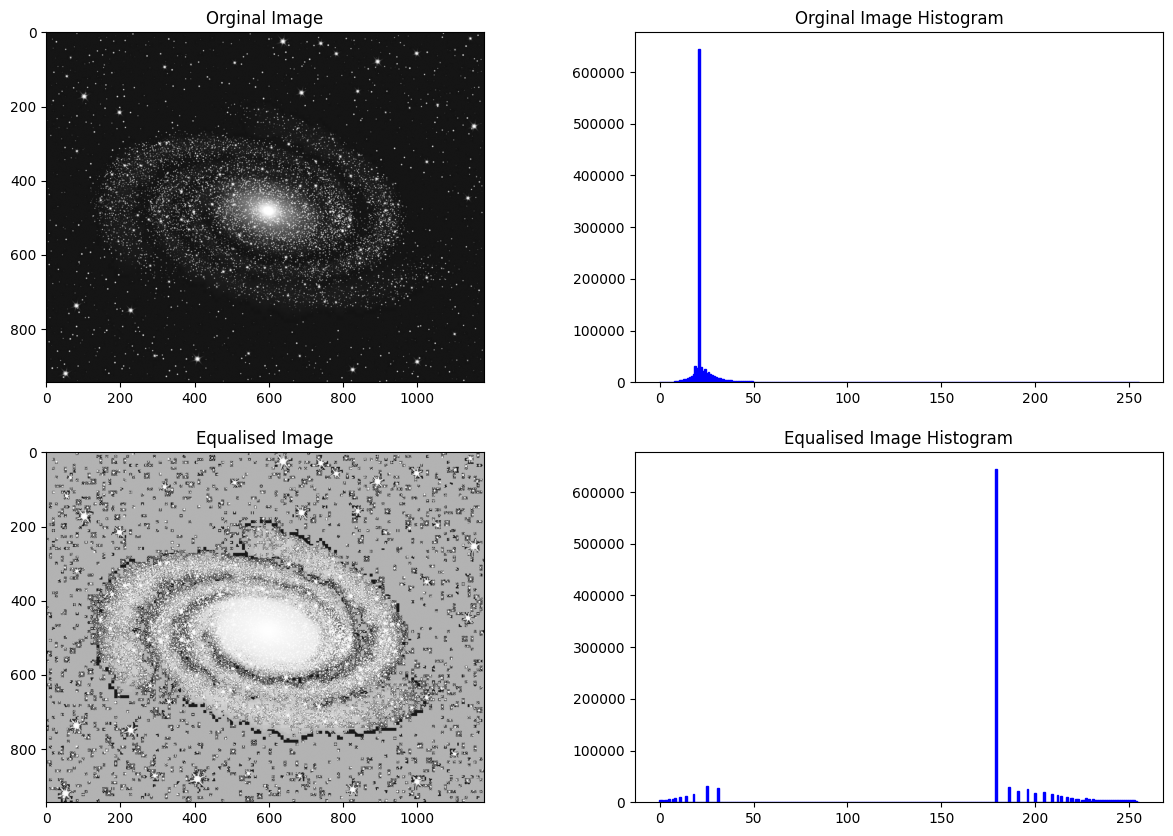

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/Milikiway.jpg', cv2.IMREAD_GRAYSCALE)

h,w = img.shape

frequency = [0]*256

for i in range(h):
    for j in range(w):
        frequency[img[i,j]] += 1

frequency = np.array(frequency)

# calculate cum sum
cdf = frequency.cumsum()

#normalise cdf
ncdf = (cdf-cdf[0])*255/(cdf[-1]-cdf[0])

equalized_img = img.copy()

for i in range(h):
    for j in range(w):
        old_val = img[i][j]
        new_val = ncdf[old_val]
        equalized_img[i,j] = new_val


# histogram of equalised img
hist = [0]*256

for i in range(h):
    for j in range(w):
        hist[equalized_img[i,j]] += 1

hist = np.array(hist)

plt.figure(figsize = (15,10))

plt.subplot(2,2,1)
plt.imshow(img, cmap ='gray')
plt.title('Orginal Image')

plt.subplot(2,2,2)
plt.bar(range(256),frequency, width=1.0, color='blue', edgecolor='blue')
plt.title('Orginal Image Histogram')

plt.subplot(2,2,3)
plt.imshow(equalized_img, cmap ='gray')
plt.title('Equalised Image')

plt.subplot(2,2,4)
plt.bar(range(256),hist, width=1.0, color='blue', edgecolor='blue')
plt.title('Equalised Image Histogram')

plt.show()

2. Some Basic Gray Level Transformations

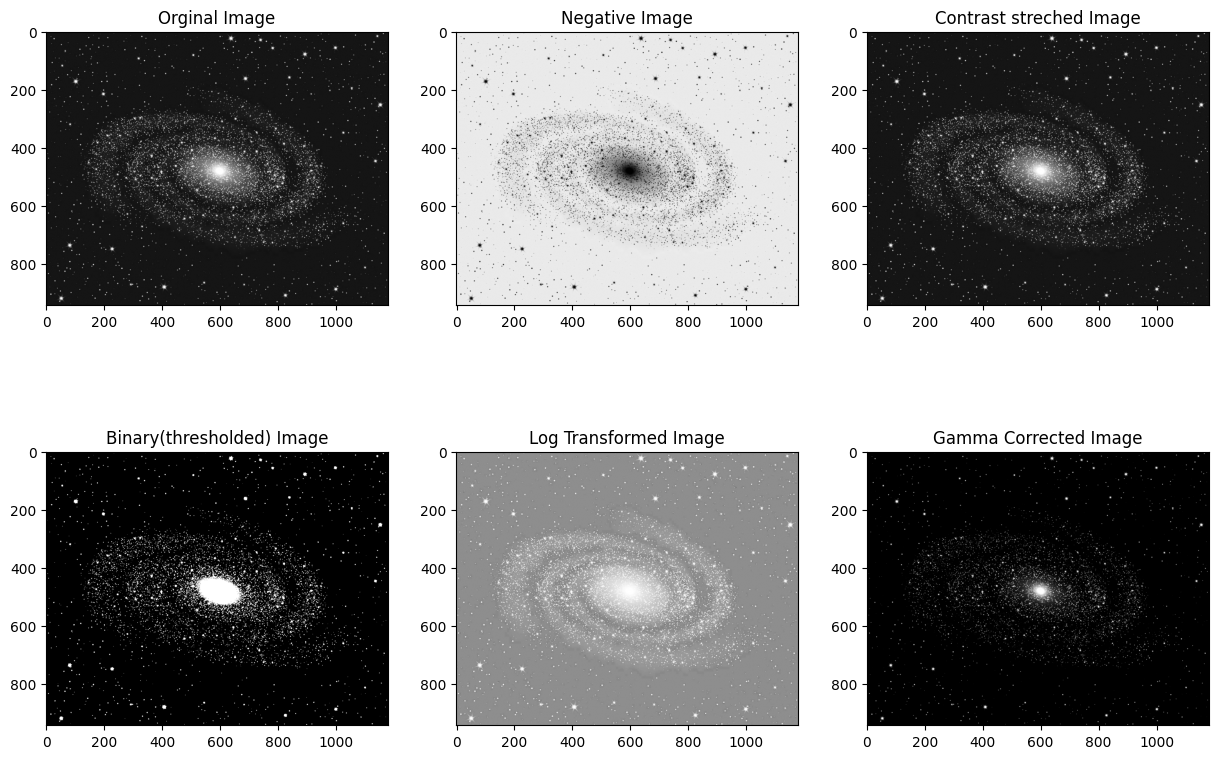

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/Milikiway.jpg', cv2.IMREAD_GRAYSCALE)
h,w = img.shape

# negative image
negImg = img.copy()
negImg = 255 - img

# contrast strched Img
strechedImg = np.zeros(img.shape, dtype= np.float64)
rmin, rmax = np.min(img), np.max(img)

strechedImg = (img-rmin)/(rmax - rmin)*255
stretchedImg = strechedImg.astype(np.uint8)  # Convert to unsigned 8-bit

# Thresholding/ binarization
T = 100
thrImg = img.copy()
for i in range(h):
    for j in range(w):
        if img[i][j] > T:
            thrImg[i][j] = 255
        else:
            thrImg[i][j] = 0


# log Transform
img_float = img.astype(float)
logImg = np.zeros(img.shape, dtype= np.float64)
c = 255/np.log(1+np.max(img_float))

logImg = c*np.log(1+ img_float)
logImg = logImg.astype(np.uint8)


#Gamma Correction/power law
img_float = img.astype(float)  # Convert once at the start to resolve uint8 overflow

# Normalize to [0, 1]
img_norm = img / 255.0

# Apply gamma correction
gamma = 2.5  # Brighten
corrected = np.power(img_norm, gamma)

# Scale back to [0, 255]
corrected = np.uint8(corrected * 255)

plt.figure(figsize = (15,10))

plt.subplot(2,3,1)
plt.imshow(img, cmap ='gray')
plt.title('Orginal Image')

plt.subplot(2,3,2)
plt.imshow(negImg, cmap ='gray')
plt.title('Negative Image')

plt.subplot(2,3,3)
plt.imshow(strechedImg, cmap ='gray')
plt.title('Contrast streched Image')

plt.subplot(2,3,4)
plt.imshow(thrImg, cmap = 'gray')
plt.title('Binary(thresholded) Image')

plt.subplot(2,3,5)
plt.imshow(logImg, cmap ='gray')
plt.title('Log Transformed Image')

plt.subplot(2,3,6)
plt.imshow(corrected, cmap ='gray')
plt.title('Gamma Corrected Image')

plt.show()


3. Gray Level Slicing

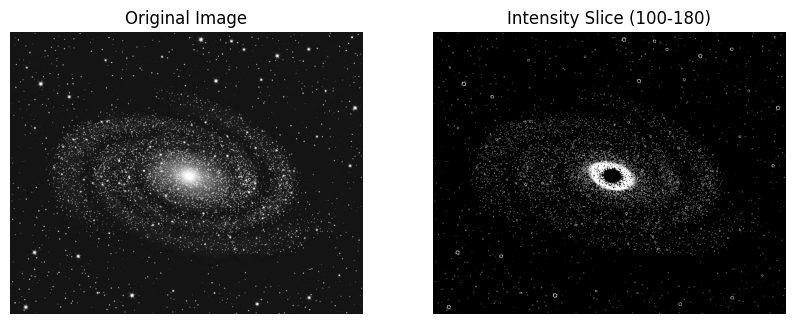

In [ ]:
import cv2
from matplotlib import pyplot as plt

# Read the image in grayscale
img = cv2.imread('/content/drive/MyDrive/DIP/Milikiway.jpg', cv2.IMREAD_GRAYSCALE)

# Define the intensity range (low and high values)
low, high = 100, 180

# Create a mask that selects pixels within the specified intensity range
gray_slice_img = cv2.inRange(img, low, high)

# Display the original and sliced images
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Image with intensity slice
plt.subplot(1, 2, 2)
plt.imshow(gray_slice_img, cmap='gray')
plt.title(f'Intensity Slice ({low}-{high})')
plt.axis('off')

plt.show()


4. Erosion, Dilation, Boundary Extraction

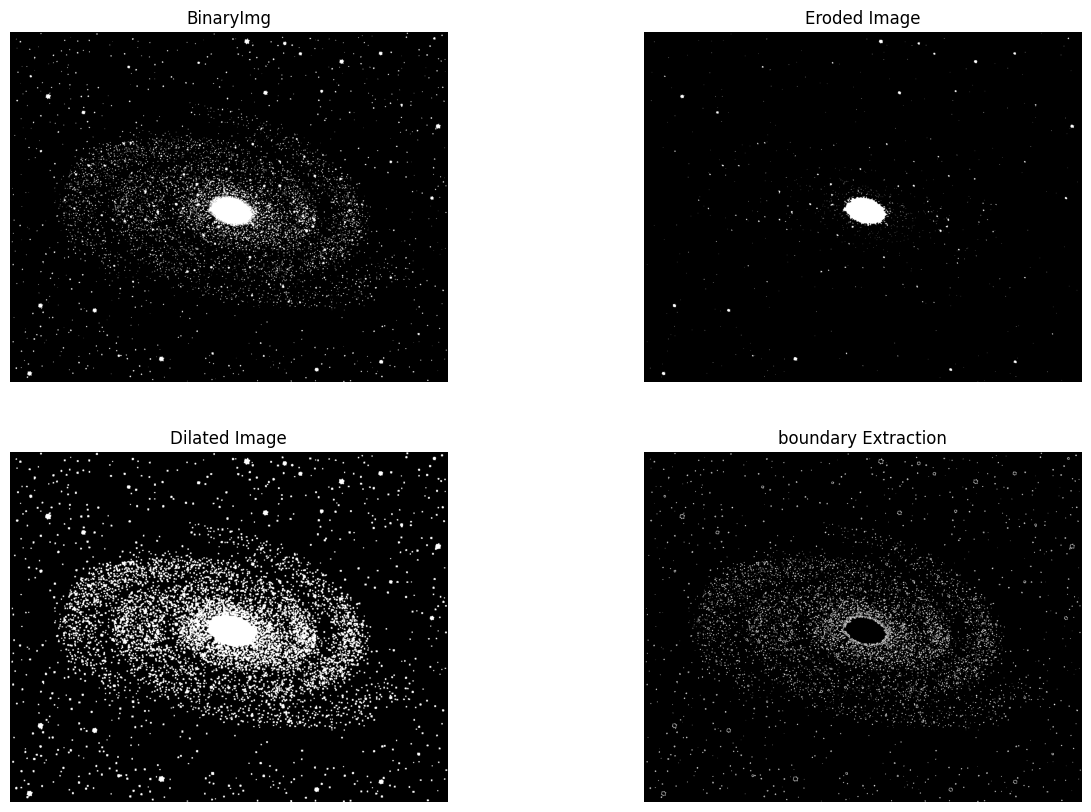

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/Milikiway.jpg', cv2.IMREAD_GRAYSCALE)

h, w = img.shape
binrayImg = img.copy()
T = 120
for i in range(h):
    for j in range(w):
        if img[i][j] >= T:
            binrayImg[i][j] = 255

        else:
            binrayImg[i][j] = 0

kernel = np.array([[1, 1, 1],
                  [1, 1, 1],
                  [1, 1, 1]])

kh, kw = kernel.shape
ph = (kh - 1)//2
pw = (kw - 1)//2

paddedImg = np.pad(binrayImg, ((ph, ph), (pw, pw)), mode ='constant', constant_values = 0)

# Erosion
erodedImg = np.zeros_like(binrayImg, dtype = np.uint8)

for i in range(ph, ph + h):
    for j in range(pw, pw + w):
        region = paddedImg[i-ph: i+ph+1, j-pw: j+pw+1]
        erodedImg[i-ph][j-pw] = np.min(region)

# Dilation
dilatedImg = np.zeros_like(binrayImg, dtype = np.uint8)
for i in range(ph, ph + h):
    for j in range(pw, pw + w):
        region = paddedImg[i-ph: i+ph+1, j-pw: j+pw+1]
        dilatedImg[i-ph][j-pw] = np.max(region)

boundary = np.zeros_like(binrayImg, dtype=np.uint8)
for i in range(h):
    for j in range(w):
        boundary[i,j] = binrayImg[i,j] - erodedImg[i,j]

plt.figure(figsize = (15, 10))

plt.subplot(2,2,1)
plt.imshow(binrayImg, cmap ='gray')
plt.title('BinaryImg')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(erodedImg, cmap ='gray')
plt.title('Eroded Image')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(dilatedImg, cmap ='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(boundary, cmap ='gray')
plt.title('boundary Extraction')
plt.axis('off')
plt.show()


5. Point Detection Image Sharpening

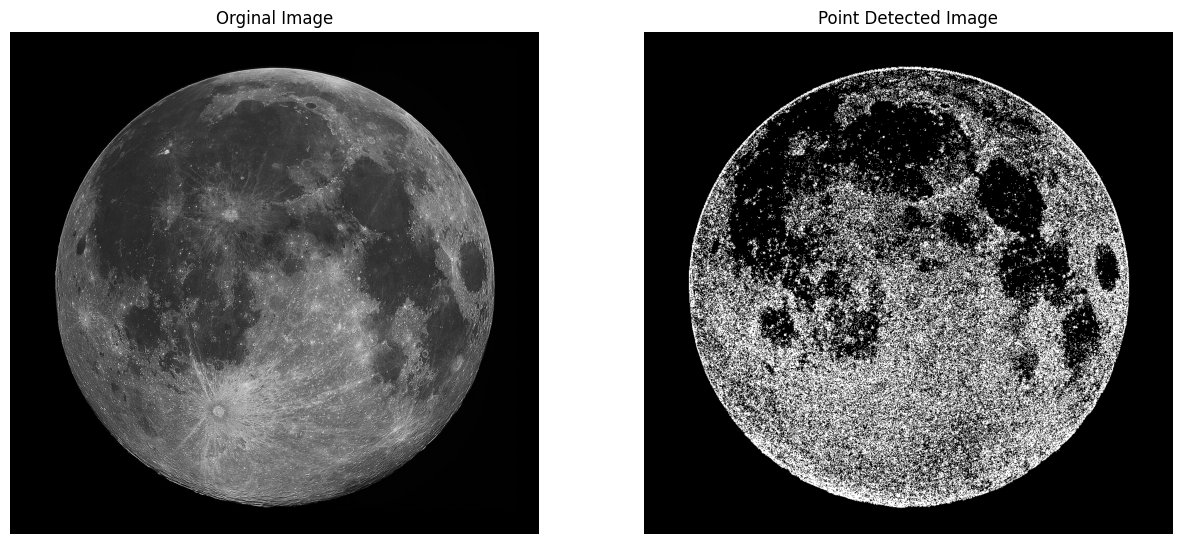

In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

img = cv2.imread('/content/drive/MyDrive/DIP/FullMoon2010.jpg', cv2.IMREAD_GRAYSCALE)
h, w = img.shape

laplacianMask = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

kh, kw = laplacianMask.shape
ph = (kh - 1)//2
pw = (kh - 1)//2

paddedImg = np.pad(img, ((ph,ph), (pw, pw)), mode ='constant', constant_values = 0)

pointDetectedImg = img.copy()
response = np.zeros(img.shape, dtype= np.float64)


for i in range(ph, ph + h):
    for j in range(pw, pw+ w):
        region = paddedImg[i-ph:i+ph+1, j-pw:j+pw+1]

        response[i-ph][j-pw] = np.sum(region * laplacianMask)

response = np.abs(response)
T = 100

for i in range(h):
    for j in range(w):
        if response[i][j]>T:
            pointDetectedImg[i][j] = 255

        else:
            pointDetectedImg[i][j] = 0


plt.figure(figsize = (15, 10))

plt.subplot(1,2,1)
plt.imshow(img, cmap ='gray')
plt.title('Orginal Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pointDetectedImg, cmap ='gray')
plt.title('Point Detected Image')
plt.axis('off')

plt.show()




6. Line Detection

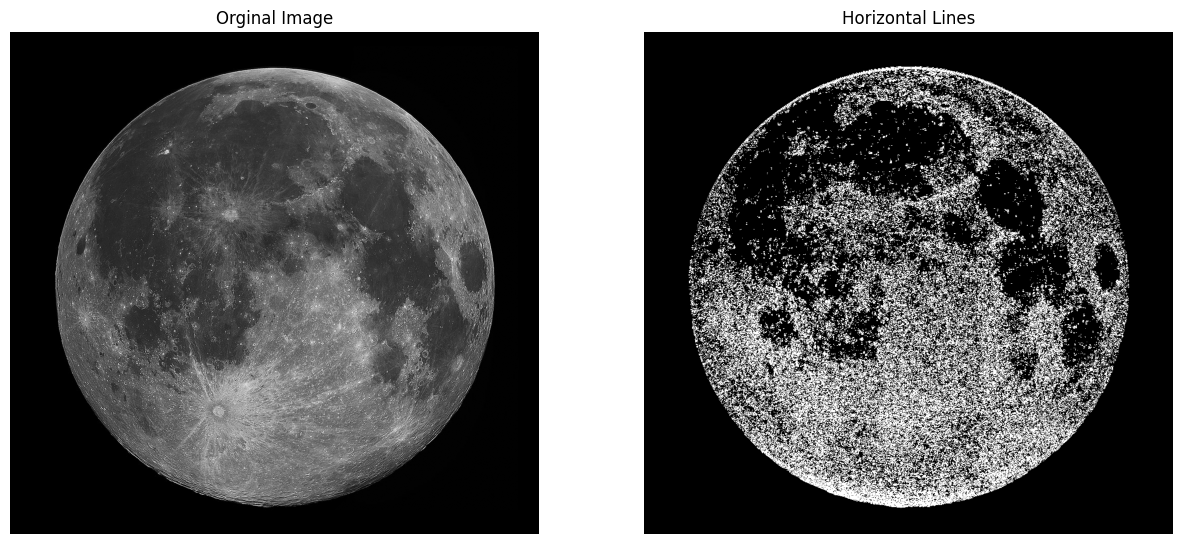

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/FullMoon2010.jpg', cv2.IMREAD_GRAYSCALE)

# Define line detection masks
# Horizontal line detector
horizontal_mask = np.array([[-1, -1, -1],
                            [ 2,  2,  2],
                            [-1, -1, -1]])

# Vertical line detector
vertical_mask = np.array([[-1,  2, -1],
                          [-1,  2, -1],
                          [-1,  2, -1]])

# +45° diagonal line detector
diagonal_45_mask = np.array([[-1, -1,  2],
                             [-1,  2, -1],
                             [ 2, -1, -1]])

# -45° diagonal line detector
diagonal_neg45_mask = np.array([[ 2, -1, -1],
                                [-1,  2, -1],
                                [-1, -1,  2]])

T = 50  # Threshold for line detection
h, w = img.shape

kh, kw = horizontal_mask.shape
ph = (kh - 1)//2
pw = (kw -1)//2
paddedImg = np.pad(img, ((ph, ph), (pw, pw)), mode ='constant', constant_values = 0)

response = np.zeros(img.shape, dtype=np.float64)
lineDetectedImg = img.copy()

for i in range(ph, ph + h):
    for j in range(pw, pw+ w):
        region = paddedImg[i -ph: i+ph+1, j - pw: j+pw+1]
        response[i-ph][j-pw] = np.sum(region*horizontal_mask)

response = np.abs(response)
T = 50

for i in range(h):
    for j in range(w):
        if response[i][j]>T:
            lineDetectedImg[i][j] = 255

        else:
            lineDetectedImg[i][j] = 0


plt.figure(figsize = (15, 10))

plt.subplot(1,2,1)
plt.imshow(img, cmap ='gray')
plt.title('Orginal Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(lineDetectedImg, cmap ='gray')
plt.title('Horizontal Lines')
plt.axis('off')

plt.show()


7. Edge Detection

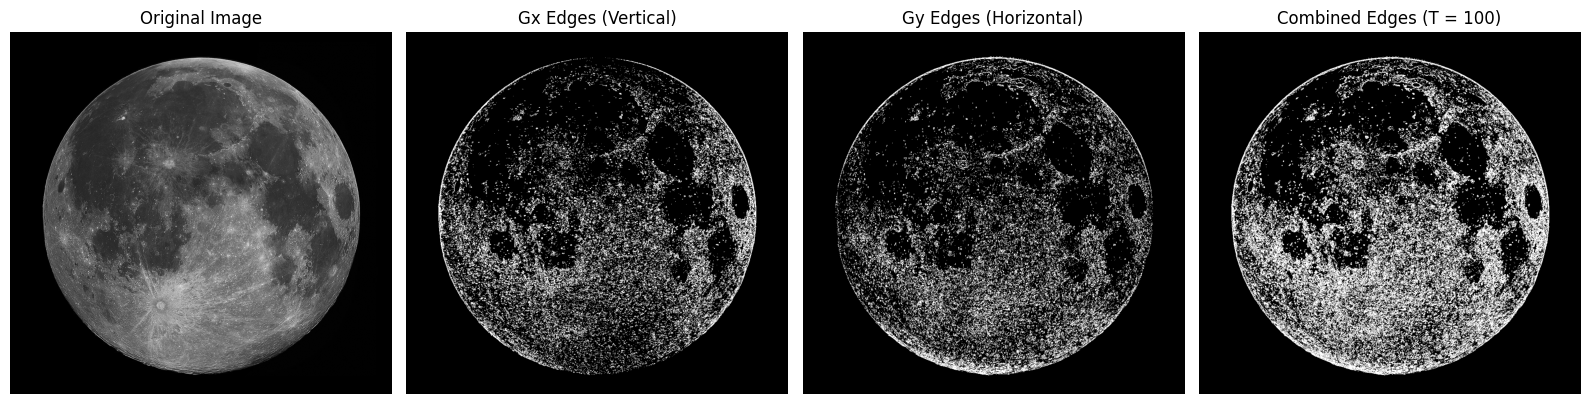

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/FullMoon2010.jpg', cv2.IMREAD_GRAYSCALE)

# Sobel operators
sobel_gx = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

sobel_gy = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]])

T = 100  # Threshold for edge detection
h, w = img.shape

kh, kw = sobel_gx.shape
ph = (kh - 1)//2
pw = (kw -1)//2

PaddedImg = np.pad(img, ((ph, ph), (pw, pw)), mode ='constant', constant_values = 0)


gx_response = np.zeros(img.shape, dtype=np.float64)
gy_response = np.zeros(img.shape, dtype=np.float64)

gxImg = img.copy()
gyImg = img.copy()
combinedImg = img.copy()

# Apply Sobel Gx (detects vertical edges)
for i in range(ph, ph + h):
    for j in range(pw, pw+ w):
        region = paddedImg[i -ph: i+ph+1, j - pw: j+pw+1]
        gx_response[i-ph][j-pw] = np.sum(region*sobel_gx)

gx_response = np.abs(gx_response)
T = 100

for i in range(h):
    for j in range(w):
        if gx_response[i][j]>T:
            gxImg[i][j] = 255

        else:
            gxImg[i][j] = 0


# Apply Sobel Gy (detects horizontal edges)
for i in range(ph, ph + h):
    for j in range(pw, pw+ w):
        region = paddedImg[i -ph: i+ph+1, j - pw: j+pw+1]
        gy_response[i-ph][j-pw] = np.sum(region*sobel_gy)

gy_response = np.abs(gy_response)


for i in range(h):
    for j in range(w):
        if gy_response[i][j]>T:
            gyImg[i][j] = 255

        else:
            gyImg[i][j] = 0



# Calculate gradient magnitude
magnitude = np.sqrt(gx_response**2 + gy_response**2)

for i in range(h):
    for j in range(w):
        if magnitude[i][j]>T:
            combinedImg[i][j] = 255

        else:
            combinedImg[i][j] = 0


# Display results
plt.figure(figsize=(16, 4))

# Original image
plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Gx edges (binary)
plt.subplot(1, 4, 2)
plt.imshow(gxImg, cmap='gray')
plt.title('Gx Edges (Vertical)')
plt.axis('off')

# Gy edges (binary)
plt.subplot(1, 4, 3)
plt.imshow(gyImg, cmap='gray')
plt.title('Gy Edges (Horizontal)')
plt.axis('off')

# Combined edges (binary)
plt.subplot(1, 4, 4)
plt.imshow(combinedImg, cmap='gray')
plt.title(f'Combined Edges (T = {T})')
plt.axis('off')

plt.tight_layout()
plt.show()


8. Blurring using Average Filter

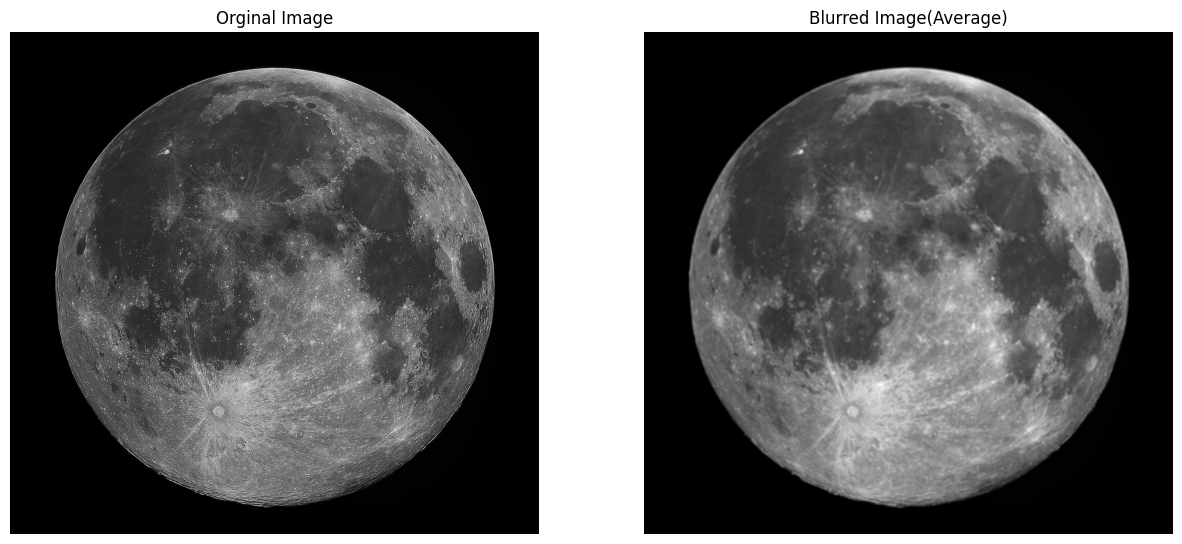

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/FullMoon2010.jpg', cv2.IMREAD_GRAYSCALE)

# 5*5 avrg filter
avgfilter = np.array([[1/25, 1/25, 1/25, 1/25, 1/25],
                      [1/25, 1/25, 1/25, 1/25, 1/25],
                      [1/25, 1/25, 1/25, 1/25, 1/25],
                      [1/25, 1/25, 1/25, 1/25, 1/25],
                      [1/25, 1/25, 1/25, 1/25, 1/25]],dtype=np.float32)


h, w = img.shape

kh, kw = avgfilter.shape
ph = (kh - 1)//2
pw = (kw -1)//2
paddedImg = np.pad(img, ((ph, ph), (pw, pw)), mode ='constant', constant_values = 0)

blurredImg = img.copy()

for i in range(ph, ph + h):
    for j in range(pw, pw+ w):
        region = paddedImg[i -ph: i+ph+1, j - pw: j+pw+1]
        blurredImg[i-ph][j-pw] = np.sum(region*avgfilter)




plt.figure(figsize = (15, 10))

plt.subplot(1,2,1)
plt.imshow(img, cmap ='gray')
plt.title('Orginal Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(blurredImg, cmap ='gray')
plt.title('Blurred Image(Average)')
plt.axis('off')

plt.show()


9. Blurring using Gaussian Filter

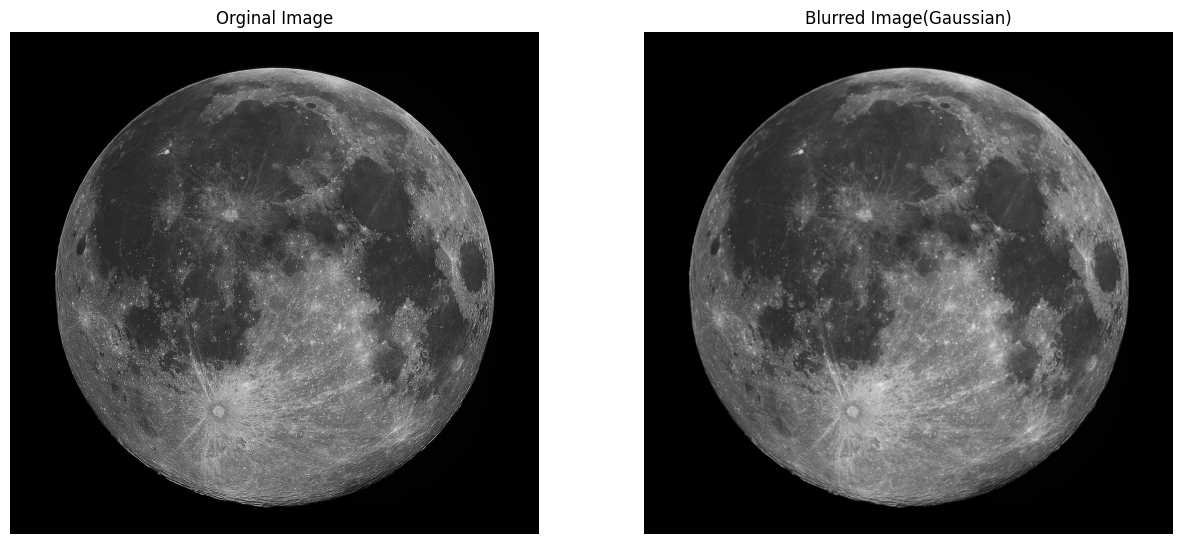

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/DIP/FullMoon2010.jpg', cv2.IMREAD_GRAYSCALE)

gaussian = np.array([[1, 2, 1],
                   [2, 4, 2],
                   [1, 2, 1]], dtype=np.float32) / 16

h, w = img.shape

kh, kw = gaussian.shape
ph = (kh - 1)//2
pw = (kw -1)//2
paddedImg = np.pad(img, ((ph, ph), (pw, pw)), mode ='constant', constant_values = 0)

blurredImg = np.zeros_like(img, dtype=np.float32)  # float for precise sum

for i in range(ph, ph + h):
    for j in range(pw, pw+ w):
        region = paddedImg[i -ph: i+ph+1, j - pw: j+pw+1]
        blurredImg[i-ph][j-pw] = np.sum(region*gaussian)


# Convert to uint8 for display
blurredImg = np.uint8(blurredImg)

plt.figure(figsize = (15, 10))

plt.subplot(1,2,1)
plt.imshow(img, cmap ='gray')
plt.title('Orginal Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(blurredImg, cmap ='gray')
plt.title('Blurred Image(Gaussian)')
plt.axis('off')

plt.show()


10. Huffman Coding

In [ ]:
import heapq

class Node:
    def __init__(self, freq, symbol=None):
        self.freq = freq
        self.symbol = symbol
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

      # For a readable printout of the Node object
    def __repr__(self):
        return f"({self.symbol}, {self.freq})"

def buildHuffmanTree(sf):
    # create pq/min heap from symbols with f
    heap = []
    for symbol, freq in sf:
        node = Node(freq, symbol)
        heapq.heappush(heap, node)

    print(heap)
    while len(heap)>1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = Node(left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

def ghcode(root, current_code="", codebook={}):
    if root is None:
        return codebook

    if root.symbol is not None:
        codebook[root.symbol] = current_code

    # Recur for left and right subtrees
    ghcode(root.left, current_code + "0", codebook)
    ghcode(root.right, current_code + "1", codebook)

    return codebook






def main():
    sf = [('A', 0.3), ('B', 0.3), ('C', 0.2), ('D', 0.1), ('E', 0.1)]
    print(sf)
    root = buildHuffmanTree(sf)

    # Generate Huffman codes
    huffman_codes = ghcode(root)

    # Print the Huffman codes
    print("Huffman Codes:")
    for symbol, code in huffman_codes.items():
        print(f"{symbol}: {code}")



main()
